# Chapter 8. 변분 양자 분류기 (VQC)

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 2**

## 학습 목표
- VQC를 처음부터 구현하기 (인코딩 → ansatz → 측정 → 학습)
- Moons 데이터셋에서 비선형 결정 경계 학습
- 학습된 회로의 decision boundary 시각화
- 클래식 ML 분류기와 정확도 비교

In [1]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

## 8.1 데이터 준비
Moons 데이터셋은 두 개의 반달이 얽혀 있어 선형 분리가 불가능하다.

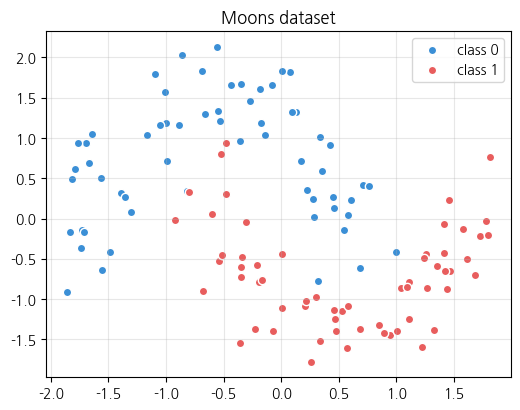

In [2]:
# 데이터 생성과 표준화
X, y = make_moons(n_samples=120, noise=0.18, random_state=0)
X = StandardScaler().fit_transform(X)
# 레이블을 -1/+1로 변환 (sign 출력과 호환)
y_pm = 2 * y - 1
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_pm, 
    test_size=0.3, 
    random_state=0
)

plt.figure(figsize=(6, 4.5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='#3b8fd6', label='class 0', edgecolor='white')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='#e85d5d', label='class 1', edgecolor='white')
plt.title('Moons dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8.2 VQC 회로 정의
구조: AngleEmbedding(인코딩) → StronglyEntanglingLayers(ansatz) → ⟨Z₀⟩(측정)

In [3]:
n_qubits = 2
n_layers = 3
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev, interface='autograd')
def vqc(x, weights):
    # 데이터 인코딩 - 두 특징을 두 큐비트의 회전 각도로
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')
    # 변분 ansatz - 학습 가능한 회전 + 얽힘
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    # 측정 - Pauli-Z 기댓값을 분류 출력으로 사용
    return qml.expval(qml.PauliZ(0))

weights_shape = qml.StronglyEntanglingLayers.shape(
    n_layers=n_layers, 
    n_wires=n_qubits
)
print('weights shape:', weights_shape)
print('파라미터 수:', np.prod(weights_shape))

rng = np.random.RandomState(7)
weights_init = rng.uniform(0, 2 * np.pi, weights_shape)
print(f'초기 출력 (예시): {vqc(X_tr[0], weights_init):.4f}')

weights shape: (3, 2, 3)
파라미터 수: 18
초기 출력 (예시): -0.1971


## 8.3 손실 함수와 학습
MSE 손실로 회로 출력이 ±1에 가까워지도록 학습한다.

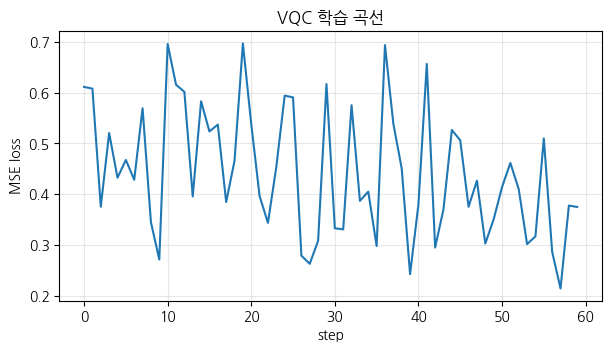

In [4]:
def mse_loss(weights, X, y):
    # 모든 학습 샘플의 회로 출력을 stack해서 한 번에 MSE 계산
    preds = pnp.stack([vqc(x, weights) for x in X])
    return pnp.mean((preds - y) ** 2)

weights = pnp.array(weights_init.copy(), requires_grad=True)
opt = qml.AdamOptimizer(0.1)

history = []
batch_size = 25
for step in range(60):
    # mini-batch 인덱스 선택
    batch_idx = rng.choice(len(X_tr), batch_size, replace=False)
    weights, loss = opt.step_and_cost(
        lambda w: mse_loss(w, X_tr[batch_idx], y_tr[batch_idx]),
        weights,
    )
    history.append(loss)

plt.figure(figsize=(7, 3.5))
plt.plot(history)
plt.xlabel('step'); plt.ylabel('MSE loss')
plt.title('VQC 학습 곡선')
plt.grid(alpha=0.3)
plt.show()

## 8.4 정확도 평가

In [5]:
# 회로 출력의 sign을 클래스 예측으로 사용
preds_tr = np.sign([vqc(x, weights) for x in X_tr])
preds_te = np.sign([vqc(x, weights) for x in X_te])
acc_tr = np.mean(preds_tr == y_tr)
acc_te = np.mean(preds_te == y_te)
print(f'학습 정확도: {acc_tr:.3f}')
print(f'테스트 정확도: {acc_te:.3f}')

# 비교: 로지스틱 회귀 (선형 분류기)
lr = LogisticRegression().fit(X_tr, y_tr)
print(f'(참고) Logistic Regression 테스트 정확도: {lr.score(X_te, y_te):.3f}')

학습 정확도: 0.893
테스트 정확도: 0.861
(참고) Logistic Regression 테스트 정확도: 0.861


## 8.5 Decision boundary 시각화
회로가 학습한 비선형 결정 경계를 그려본다.

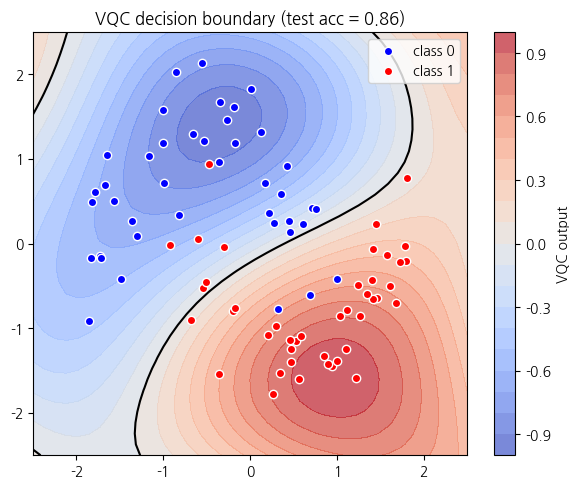

In [6]:
# Grid에서 회로 출력값을 계산
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 40), np.linspace(-2.5, 2.5, 40))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([vqc(pt, weights) for pt in grid]).reshape(xx.shape)

plt.figure(figsize=(7, 5.5))
plt.contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.7)
plt.colorbar(label='VQC output')
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=1.5)
plt.scatter(
    X_tr[y_tr == -1, 0], 
    X_tr[y_tr == -1, 1], 
    c='blue', edgecolor='white', 
    label='class 0'
)
plt.scatter(
    X_tr[y_tr == 1, 0], 
    X_tr[y_tr == 1, 1], 
    c='red', edgecolor='white', 
    label='class 1'
)
plt.title(f'VQC decision boundary (test acc = {acc_te:.2f})')
plt.legend()
plt.show()

## 8.6 정리
- VQC는 "인코딩 → ansatz → 측정 → sign"의 ML 모델이다.
- Moons처럼 선형 분리 불가능한 데이터도 비선형 경계로 학습 가능하다.
- 다음 장에서는 같은 데이터를 양자 커널과 SVM 조합으로 풀어본다.